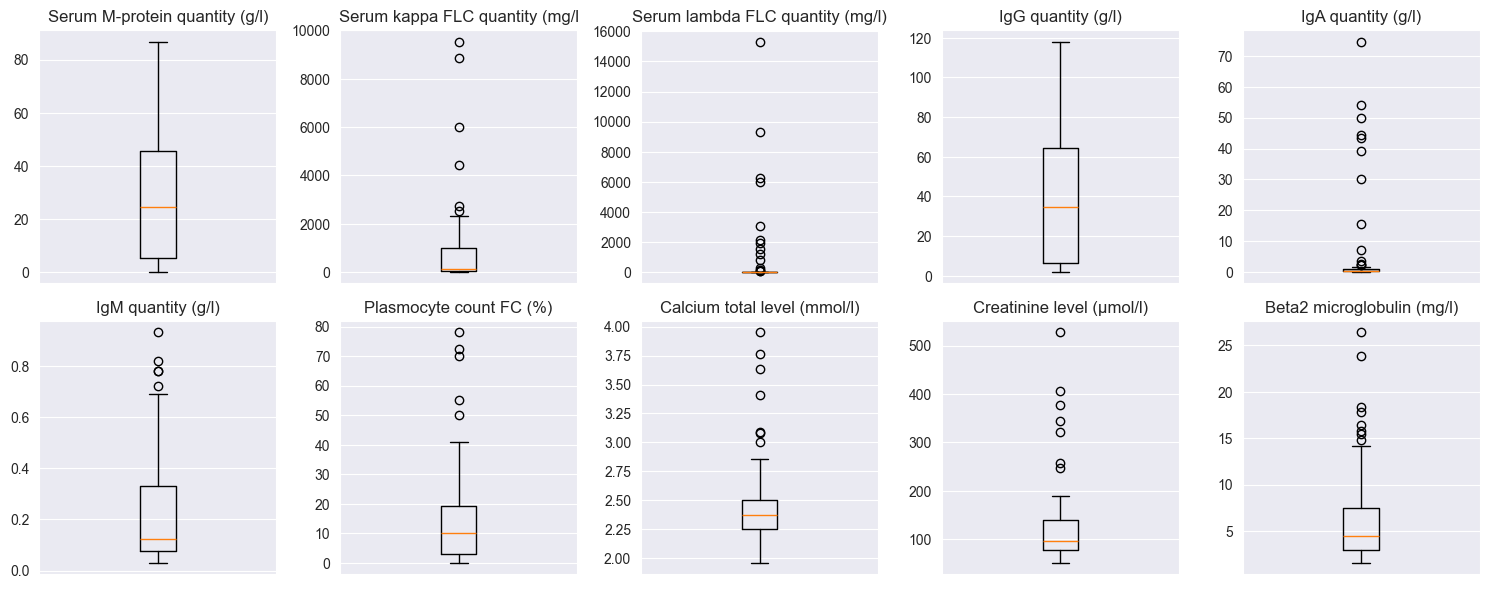

In [1]:
# BOXPLOT VISUALIZATION
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

numeric_cols = df.select_dtypes(include=['number']).columns

cols_per_row = 5
rows = (len(numeric_cols) + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(cols_per_row*3, rows*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols_per_row, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(col, fontsize=12)
    plt.xticks([])
plt.tight_layout()
plt.show()

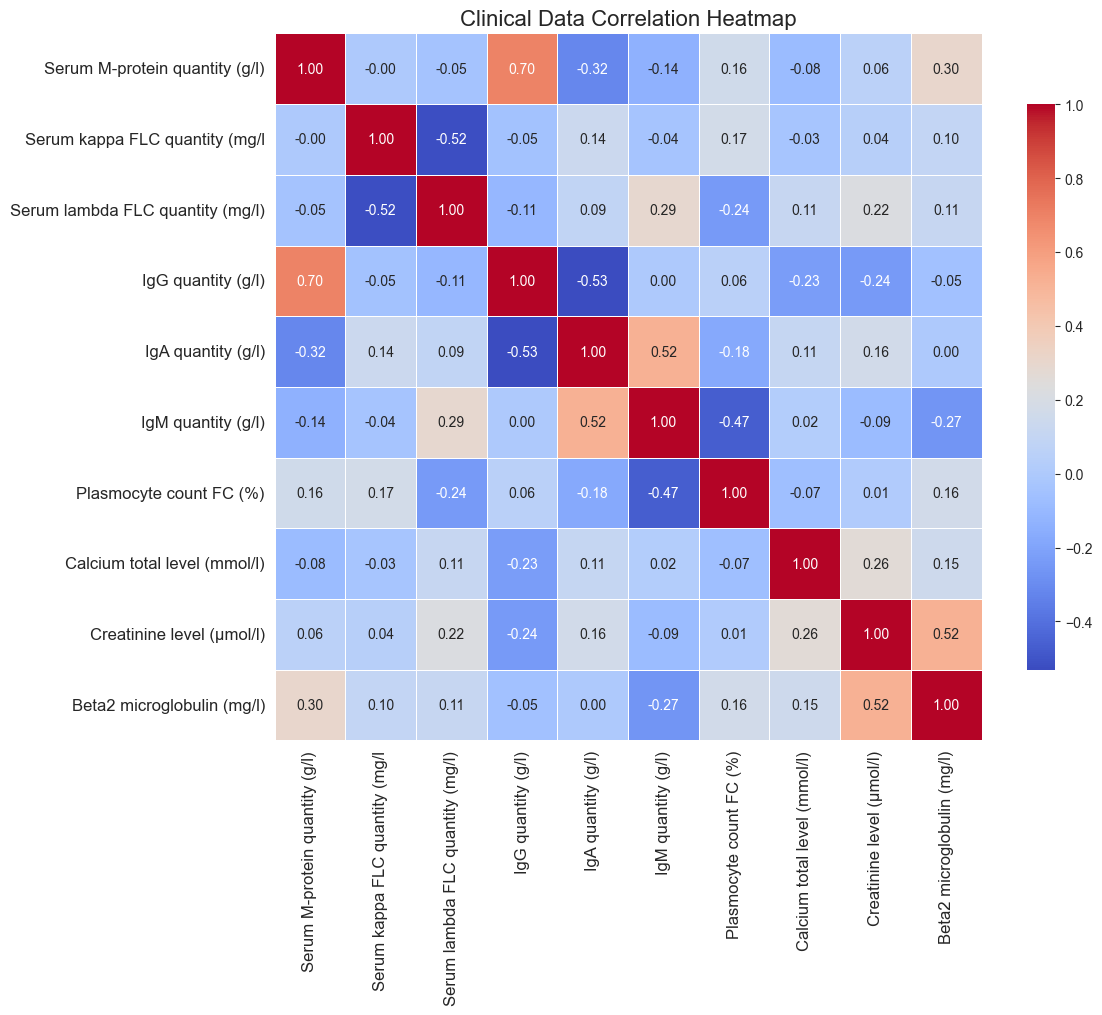

In [2]:
# SPEARMAN HEATMAP
import seaborn as sns


plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr(method="spearman")  # pearson/spearman
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Clinical Data Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

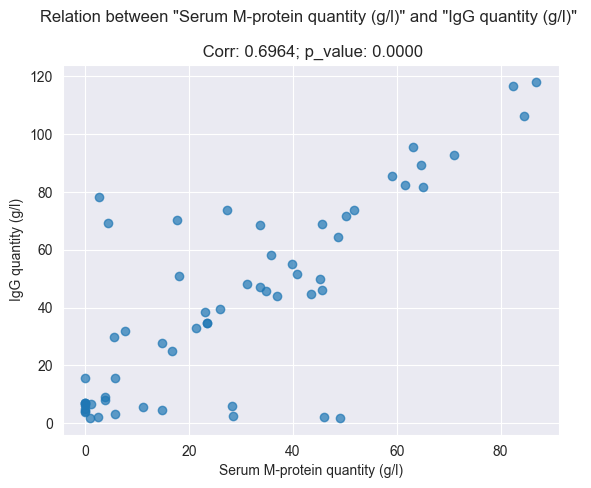

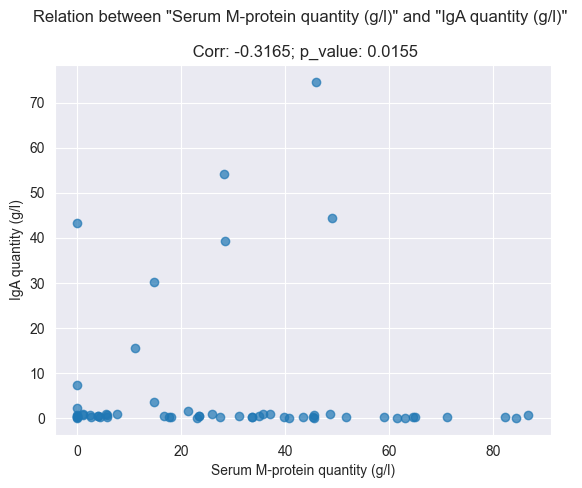

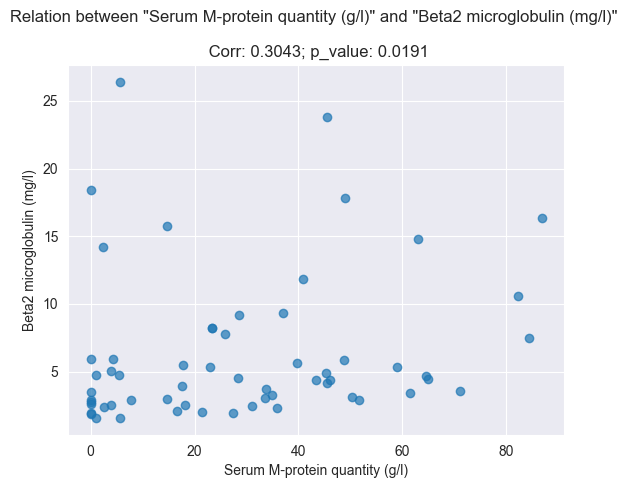

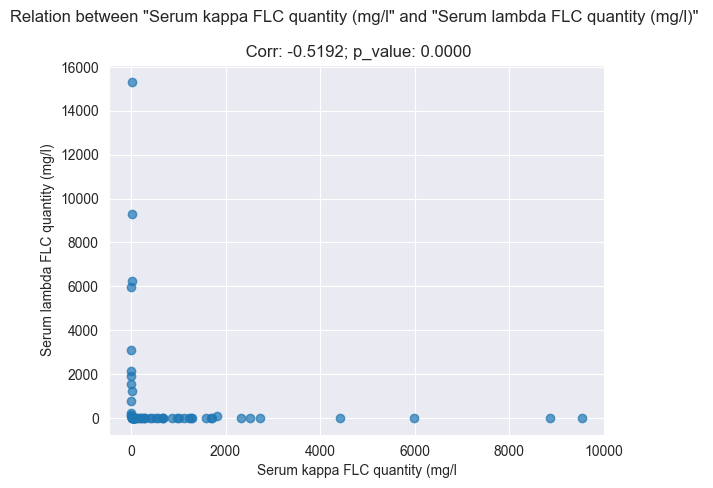

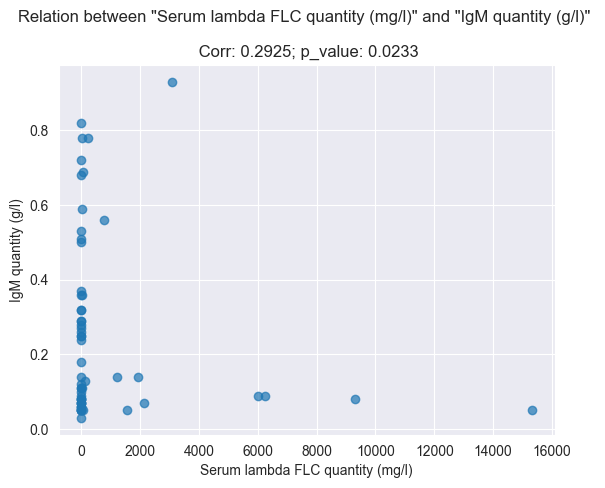

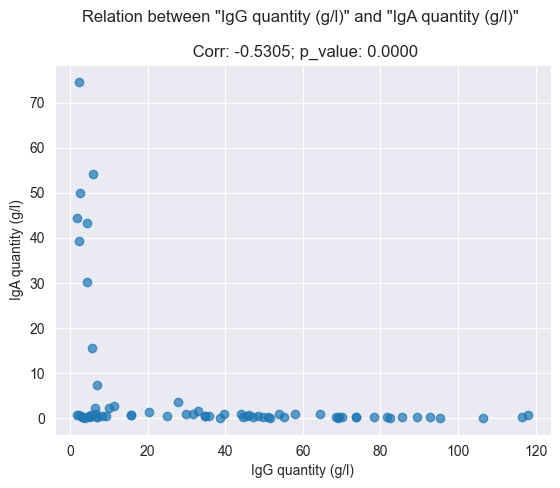

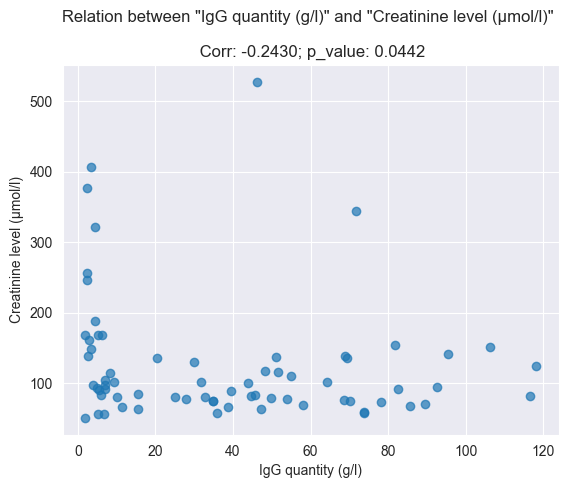

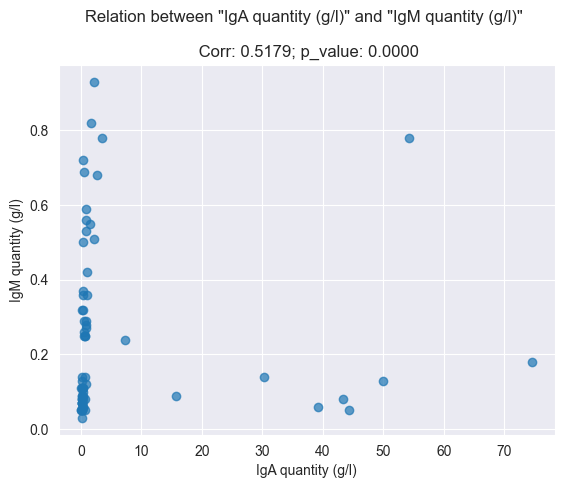

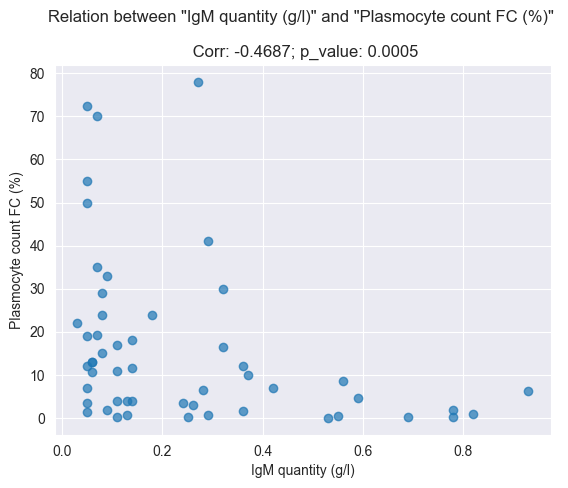

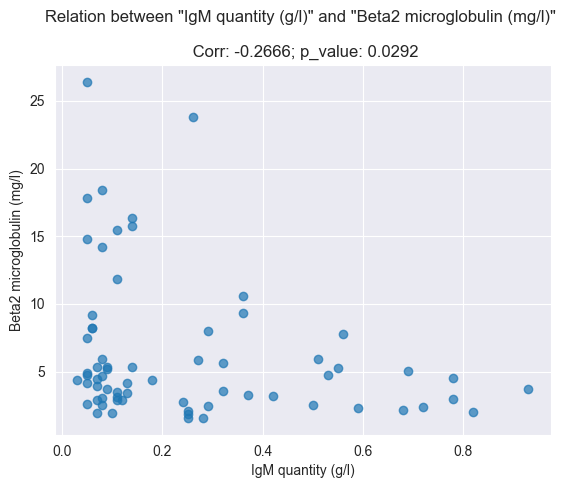

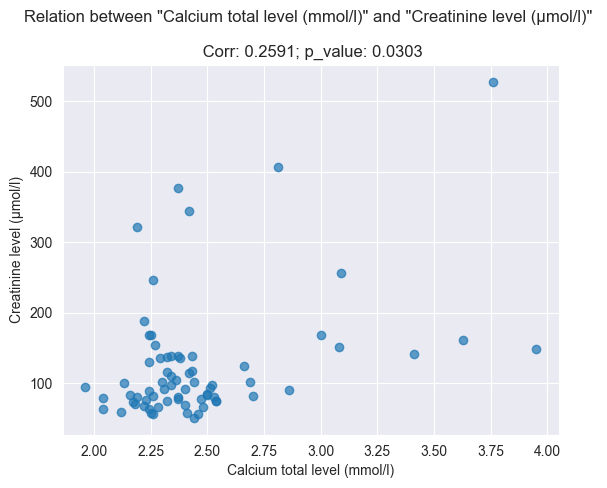

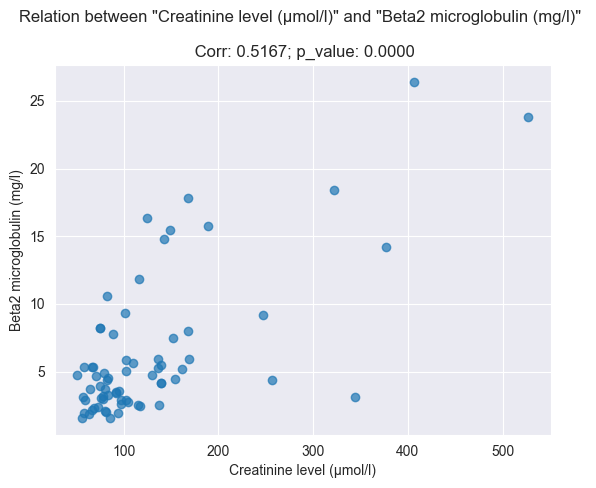

In [3]:
# SCATTER PLOT BETWEEN NUMERIC VARIABLES -> SPEARMAN TEST
from scipy.stats import spearmanr
from itertools import combinations


for f1, f2 in list(combinations(numeric_cols, 2)):
    corr, p_value = spearmanr(df[f1], df[f2], nan_policy='omit')
    if p_value < 0.05:
        plt.scatter(df[f1], df[f2], alpha=0.7)
        plt.xlabel(f1)
        plt.ylabel(f2)
        plt.title(f'Relation between "{f1}" and "{f2}" \n\n Corr: {corr:.4f}; p_value: {p_value:.4f}', fontsize=12)
        plt.show()
        print()

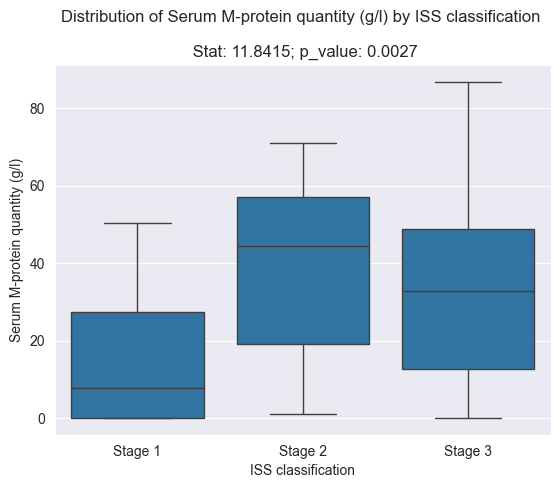

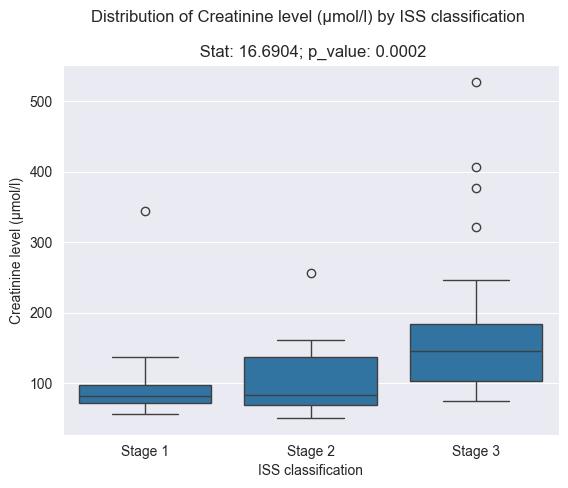

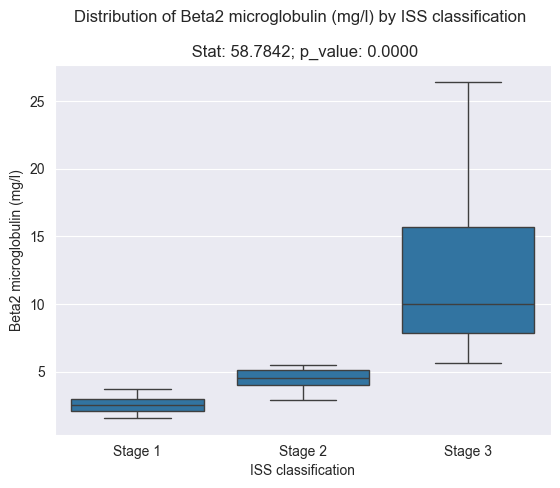

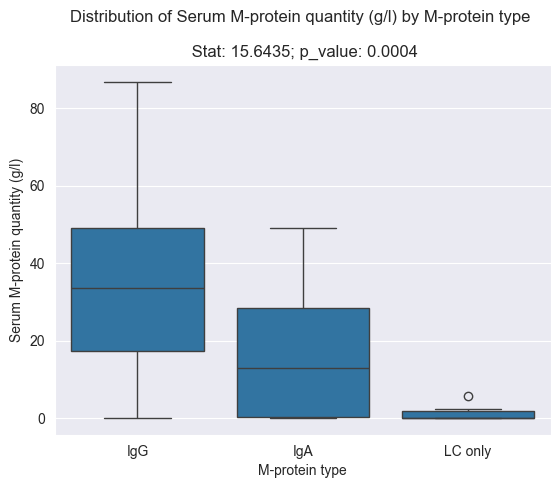

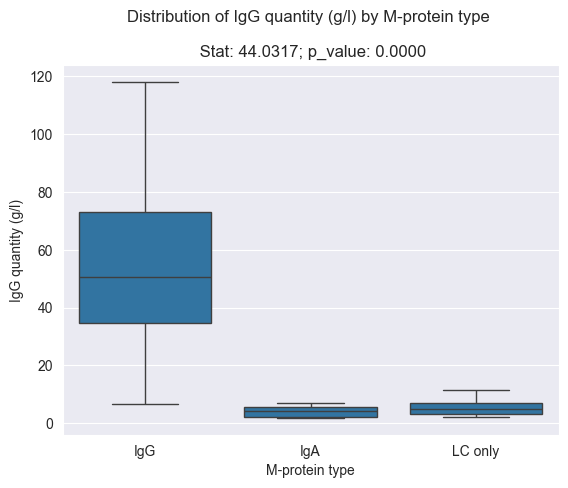

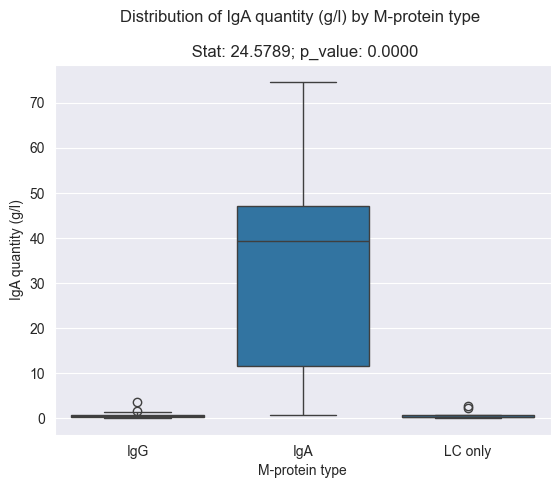

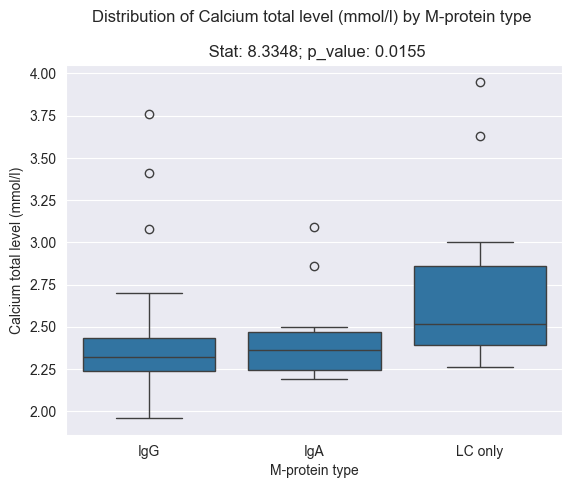

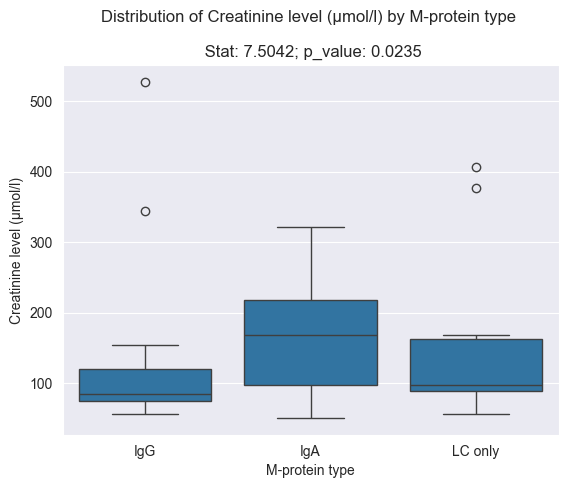

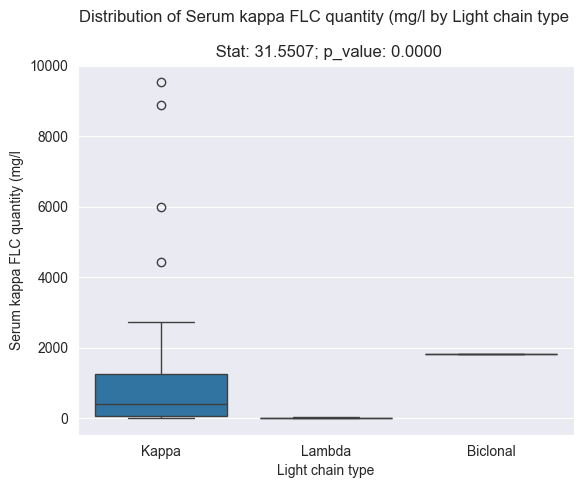

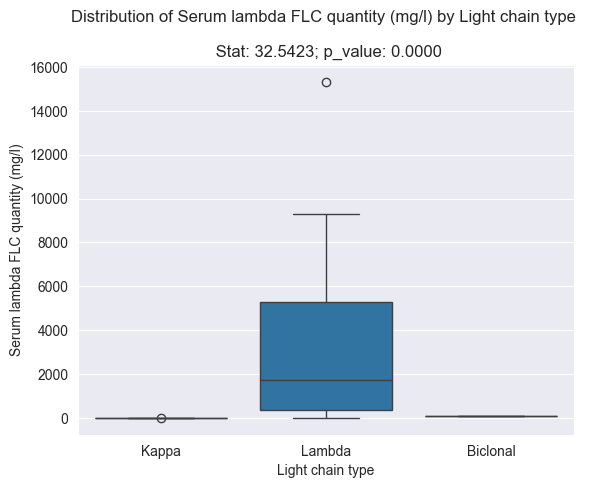

In [4]:
# BOXPLOT BETWEEN NUMERIC AND CATEGORIC VARIABLES -> KRUSKAL-WALLIS TEST
from scipy.stats import kruskal


categorical_cols = ['ISS classification', 'M-protein type', 'Light chain type']
for cat_col in categorical_cols:
    for num_col in numeric_cols:
        groups = [group[num_col].dropna().values for name, group in df.groupby(cat_col)]

        stat, p = kruskal(*groups)
        if p < 0.05:
            sns.boxplot(data=df, x=cat_col, y=num_col)
            plt.title(f'Distribution of {num_col} by {cat_col} \n\n Stat: {stat:.4f}; p_value: {p:.4f}')
            plt.show()
            print()

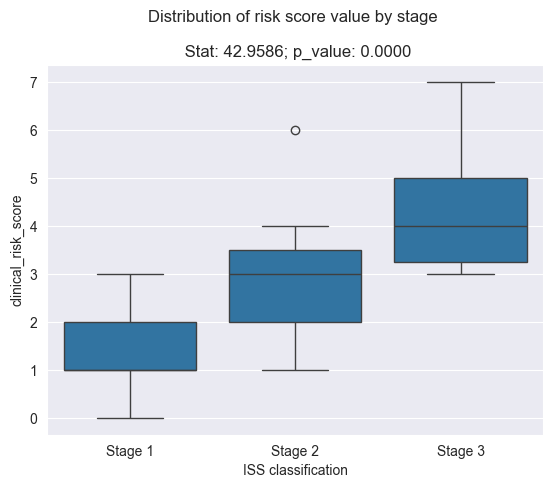

In [53]:
# RISK SCORE CALCULATION
df['kappa lambda ratio'] = df['Serum kappa FLC quantity (mg/l'] / df['Serum lambda FLC quantity (mg/l)']

df["score_tumor_burden"] = 0
df.loc[df["Serum M-protein quantity (g/l)"] > 30, "score_tumor_burden"] += 1
df.loc[df["Plasmocyte count FC (%)"] > 30, "score_tumor_burden"] += 1
df.loc[df["kappa lambda ratio"] > 100, "score_tumor_burden"] += 1

df["score_clone"] = 0
df.loc[df["M-protein type"] == "IgA", "score_clone"] = 1
df.loc[df["M-protein type"] == "IgG", "score_clone"] = 1
df.loc[df["M-protein type"] == "Light-chain", "score_clone"] = 2

df["score_CRAB"] = 0
df.loc[df["Calcium total level (mmol/l)"] > 2.75, "score_CRAB"] += 1
df.loc[df["Creatinine level (µmol/l)"] > 177, "score_CRAB"] += 1

df["score_prognosis"] = 0
df.loc[(df["Beta2 microglobulin (mg/l)"] >= 3.5) & (df["Beta2 microglobulin (mg/l)"] < 5.5), "score_prognosis"] = 1
df.loc[df["Beta2 microglobulin (mg/l)"] >= 5.5, "score_prognosis"] = 2

df["clinical_risk_score"] = (
    df["score_tumor_burden"] +
    df["score_clone"] +
    df["score_CRAB"] +
    df["score_prognosis"]
)

groups = [group["clinical_risk_score"].dropna().values for name, group in df.groupby("ISS classification")]
stat, p = kruskal(*groups)
sns.boxplot(data=df, x="ISS classification", y="clinical_risk_score")
plt.title(f'Distribution of risk score value by stage \n\n Stat: {stat:.4f}; p_value: {p:.4f}', fontsize=12)
plt.show()

In [54]:
# CHI SQUARED TEST BETWEEN M-PROTEIN TYPE AND STAGE
from scipy.stats import chi2_contingency


ct = pd.crosstab(df['M-protein type'], df['ISS classification'])
print(ct)
print()
chi2, p, dof, expected = chi2_contingency(ct)
print(f"p-value = {p}")

ISS classification  Stage 1  Stage 2  Stage 3
M-protein type                               
IgA                       1        4        5
IgG                      16       18       13
LC only                   7        1        4

p-value = 0.1024800095387706
